# Data

In [1]:
from torchvision import datasets
import os
import kagglehub

# Download latest version
DATA_PATH = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")
IMG_PATH = os.path.join(DATA_PATH, "images", "Images")
ANNOTATION_PATH = os.path.join(DATA_PATH, "annotations", "Annotations")

print("Path to dataset files:", DATA_PATH)

dataset = datasets.ImageFolder(root=IMG_PATH)

/home/franio/Desktop/Explainable_AI/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/franio/.cache/kagglehub/datasets/jessicali9530/stanford-dogs-dataset/versions/2


# Model, Transform and Prediction

In [2]:
import torch
from utils.metric_functions import test_on_given_idx
from torchvision.models import resnet
from torchvision import transforms
import numpy as np


MODEL_NAME = 'resnet18_dogs_5_epochs'

net_model = resnet.resnet18()
net_model.load_state_dict(torch.load(os.path.join('models', f"{MODEL_NAME}.pth"), weights_only=True))

#transforms for prediction
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
transform = transforms.Compose([transforms.Resize((224,224)),
                                         transforms.ToTensor(),
                                         transforms.Normalize(mean, std)])

idx = np.random.choice(np.arange(start=0, stop=len(dataset)), size=6, replace=False)
preds, df = test_on_given_idx(dataset, net_model,transform, idx=idx)
df

,Idx,True_Label,Predicted_Label
0,16427,n02109525-Saint_Bernard,n02109525-Saint_Bernard
1,7616,n02096177-cairn,n02096177-cairn
2,13352,n02105505-komondor,n02105505-komondor
3,6197,n02094114-Norfolk_terrier,n02094114-Norfolk_terrier
4,5287,n02093428-American_Staffordshire_terrier,n02091032-Italian_greyhound
5,11697,n02102040-English_springer,n02102040-English_springer


# Plot Images

array([16427,  7616, 13352,  6197,  5287, 11697])

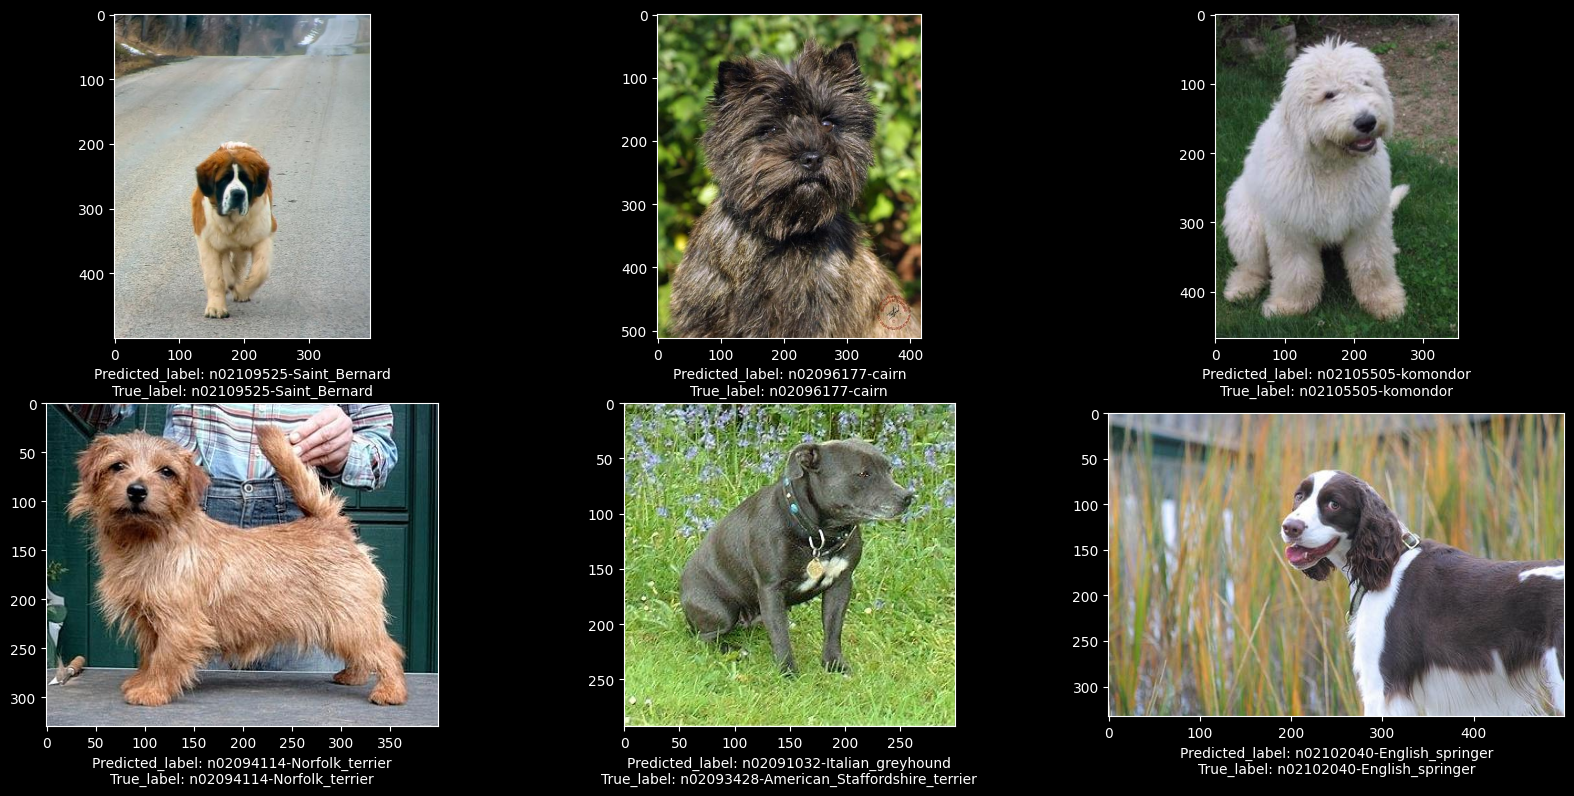

In [3]:
from utils.plot import plot_idx_labeled

plot_idx_labeled(idx,preds,dataset)

# Explanation via LIME